In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time

#ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
#coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

In [11]:
hires = '/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/hires'
coorhires = rlp.io.read_trajectory(f'{hires}.h5')
coorhires = np.asarray(coorhires)
kspacehires = rlp.io.read_data(f'{hires}.h5')
kspacehires = np.asarray(kspacehires)
kspacehires = kspacehires[0, 0] 
kspacehires = np.moveaxis(kspacehires, -1, 0)


print(coorhires.shape)

(16128, 122, 3)


In [13]:
import h5py
def h5tonum(file, showshape=False):
    with h5py.File(file) as f:     
        d = f['data'][:]             
        traj = f['trajectory'][:]
        d = d[0,:,0]
        traj = np.moveaxis(traj,-1,0)
        if showshape == True:
            print(d.shape)
            print(traj.shape)
    return d, traj

riesling_im, traj = h5tonum('/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/hires-nufft.h5', showshape=True)
riesling_cartksp = sp.fft(riesling_im)


(44, 126, 126, 126)
(3, 16128, 122)


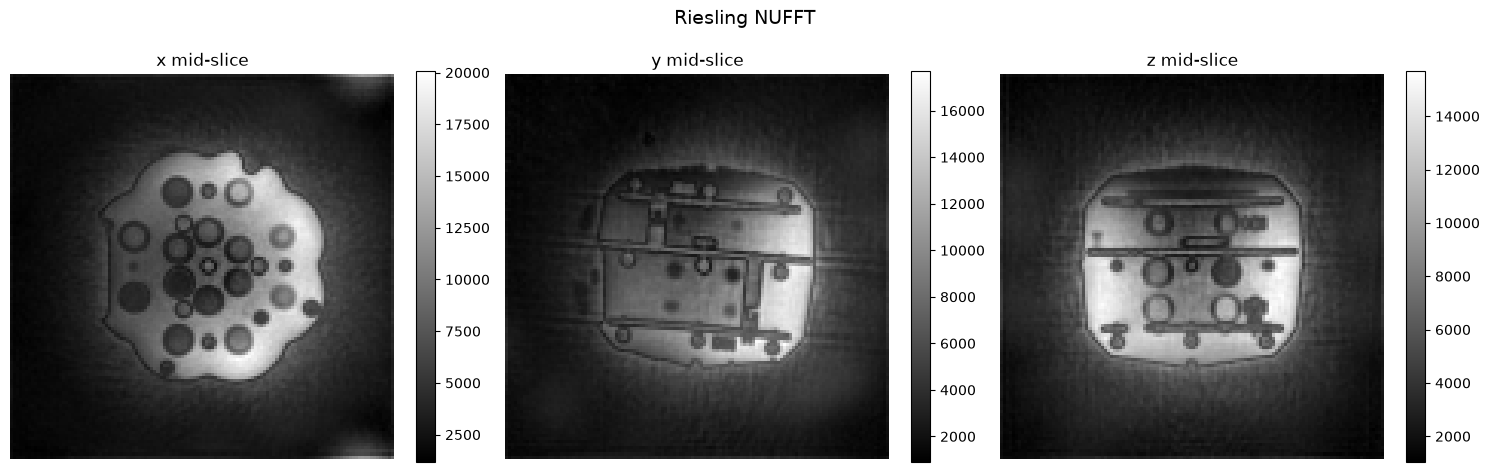

In [14]:
def plot_planes(kspace, title, savefig=None):
    im_grid = sp.ifft(kspace)
    rss = np.sum(np.abs(im_grid)**2, axis=0)**0.5

    nx, ny, nz = rss.shape
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14)

    for ax, (sl, sl_title) in zip(axes, [
        (rss[nx // 2, :, :], 'x mid-slice'),
        (rss[:, ny // 2, :], 'y mid-slice'),
        (rss[:, :, nz // 2], 'z mid-slice'),
    ]):
        img = ax.imshow(np.abs(sl), cmap='gray')
        ax.set_title(sl_title)
        ax.axis('off')
        fig.colorbar(img, ax=ax, fraction=0.046)

    plt.tight_layout()
    if savefig is not None:
        fig.savefig(savefig, dpi=300, bbox_inches='tight')
    plt.show()

plot_planes(riesling_cartksp, title='Riesling NUFFT')

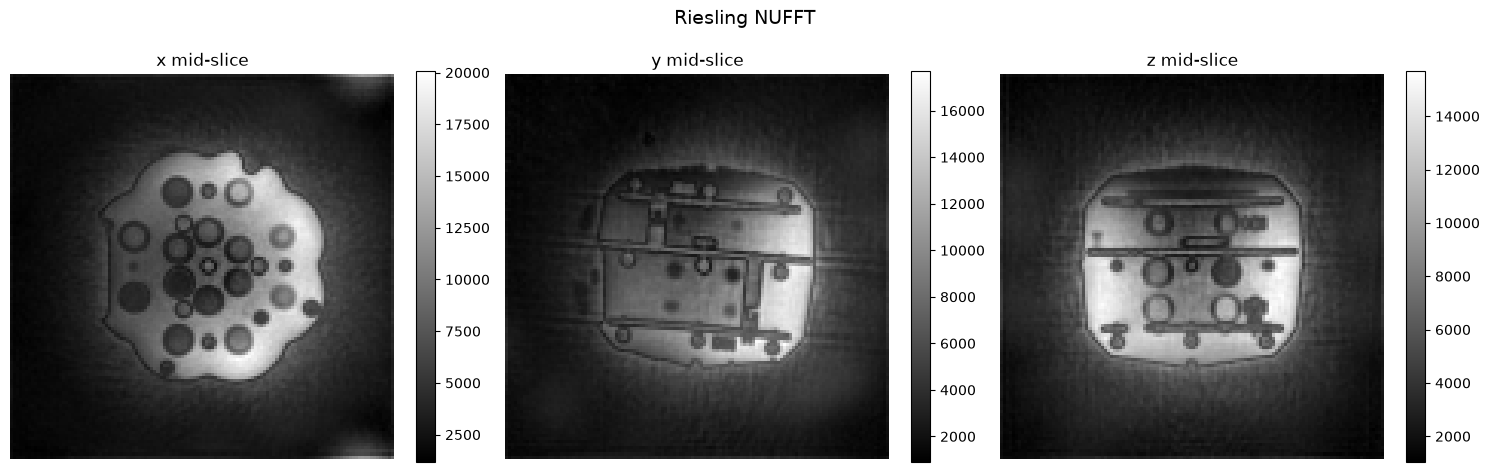

In [5]:
riesling_sp_imgrid = np.sum(np.abs(riesling_im)**2, axis=0)**0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Riesling NUFFT', fontsize=14)
nx, ny, nz = riesling_sp_imgrid.shape
for ax, (sl, title) in zip(axes, [
    (riesling_sp_imgrid[nx // 2, :, :], 'x mid-slice'),
    (riesling_sp_imgrid[:, ny // 2, :], 'y mid-slice'),
    (riesling_sp_imgrid[:, :, nz // 2], 'z mid-slice'),
]):
    im = ax.imshow(np.abs(sl), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046)
#fig.savefig('riesling_recon.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

#rlp.plot.planes('hires-nufft.h5', title='Riesling NUFFT with rl.plot')

## Goal of the notebook

### Integrate riesling into sigpy pipeline

1. Start with NUFFT inverse

- get the above file format into something that riseling can read

In [6]:
def zeropadding3d(cart_kspace,resize_factor):
    resize = cart_kspace.shape[1]*resize_factor
    n_coils = cart_kspace.shape[0]
    image_grid = sp.ifft(cart_kspace)
    enlarged_image_grid = sp.resize(image_grid, [n_coils,resize, resize, resize])
    enlarged_cartesian_kspace = sp.fft(enlarged_image_grid, axes=(-3, -2, -1))
    return enlarged_cartesian_kspace


def zeropadding3d_fromim(im_grid,resize_factor):
    resize = im_grid.shape[1]*resize_factor
    n_coils = im_grid.shape[0]
    enlarged_image_grid = sp.resize(im_grid, [n_coils,resize, resize, resize])
    enlarged_cartesian_kspace = sp.fft(enlarged_image_grid, axes=(-3, -2, -1))
    return enlarged_cartesian_kspace

In [7]:
enlarged_cartesian = zeropadding3d(riesling_cartksp, resize_factor=2)
enlarged_cartesian.shape

(44, 252, 252, 252)

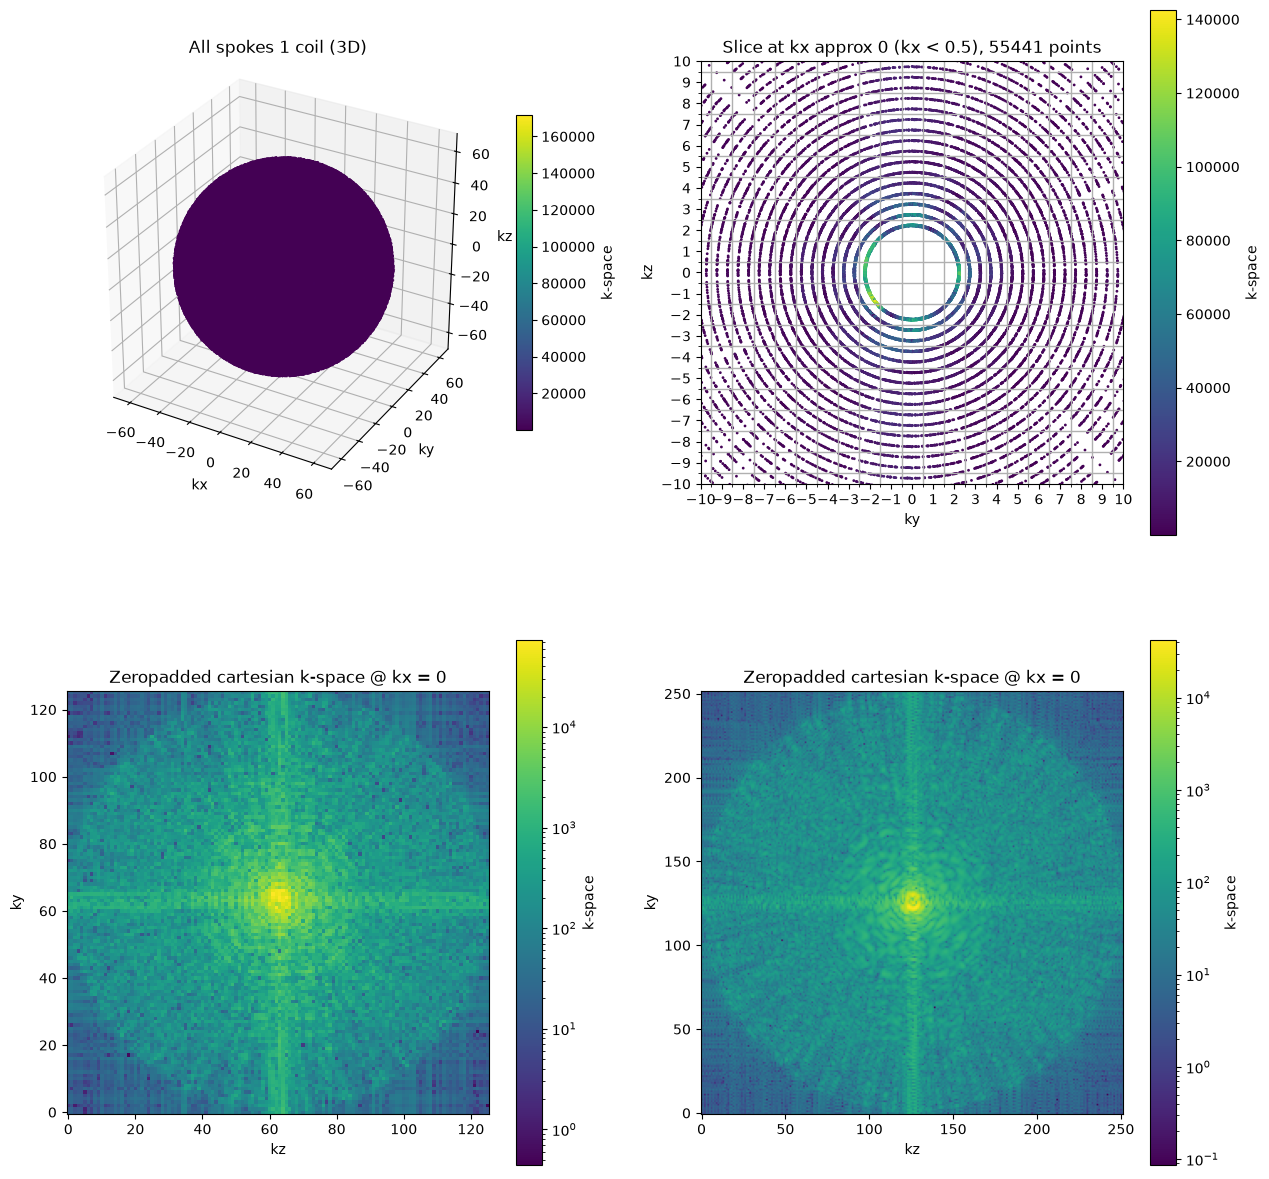

In [8]:
all_ztecoords= coorhires.reshape(-1,3)
all_zteksp = kspacehires.reshape(-1)


fig = plt.figure(figsize=(15,15))

# --- Subplot 1: full 3D trajectory ---
ax0 = fig.add_subplot(2, 2, 1, projection='3d')
im0 = ax0.scatter(
    all_ztecoords[:, 0], all_ztecoords[:, 1], all_ztecoords[:, 2],
    c=np.abs(kspacehires[0]).reshape(-1),
    s=1
)
ax0.set_title('All spokes 1 coil (3D)')
ax0.set_xlabel('kx')
ax0.set_ylabel('ky')
ax0.set_zlabel('kz')
ax0.set_box_aspect((1, 1, 1))
fig.colorbar(im0, ax=ax0, label='k-space', shrink=0.6)

# --- Subplot 2: slice near kx = 0 (2D view of ky-kz plane) ---
ax1 = fig.add_subplot(2, 2, 2)  

tol = 0.5  # slab half-thickness; adjust to your coordinate units
maskztevis = np.abs(all_ztecoords[:, 0]) < tol

im1 = ax1.scatter(
    all_ztecoords[maskztevis, 1], all_ztecoords[maskztevis, 2],
    c=np.abs(kspacehires[0]).reshape(-1)[maskztevis],
    s=1
)
ax1.set_title(f'Slice at kx approx 0 (kx < {tol}), {maskztevis.sum()} points')
ax1.set_xlabel('ky')
ax1.set_ylabel('kz')
ax1.set_aspect('equal')
ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.yaxis.set_major_locator(plt.MultipleLocator(1))
ax1.grid(visible=True, which='minor', linewidth=1)
ax1.xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax1.set_xlim(-10,10)
ax1.set_ylim(-10,10)
#ax1.axis('equal')
fig.colorbar(im1, ax=ax1, label='k-space')

ax2 = fig.add_subplot(2, 2, 3)

grid_vol = np.abs(riesling_cartksp[0])
kx_centre = grid_vol.shape[0] // 2  # kx = 0 lives at the centre index

im2 = ax2.imshow(
    grid_vol[kx_centre],
    origin='lower',
    norm=matplotlib.colors.LogNorm()  # k-space dynamic range is huge
)
ax2.set_title('Zeropadded cartesian k-space @ kx = 0')
ax2.set_xlabel('kz')
ax2.set_ylabel('ky')
fig.colorbar(im2, ax=ax2, label='k-space')

ax2 = fig.add_subplot(2, 2, 4)

grid_vol_zeropadding = np.abs(enlarged_cartesian[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2  # kx = 0 lives at the centre index

im2 = ax2.imshow(
    grid_vol_zeropadding[kx_centre_large],
    origin='lower',
    norm=matplotlib.colors.LogNorm()  # k-space dynamic range is huge
)
ax2.set_title('Zeropadded cartesian k-space @ kx = 0')
ax2.set_xlabel('kz')
ax2.set_ylabel('ky')
fig.colorbar(im2, ax=ax2, label='k-space')
plt.show()


In [9]:
width=4
gap = 3
num_iters = 50


inner_wid=26
indiv2 = int(inner_wid/2)

In [10]:
def inner_portion(enlarged_kspace, inner_sidelen):

    cx, cy, cz = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2, enlarged_kspace.shape[3] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end, start:end]
    
    return(isolated_kspace, isolation_mask, start, end)

inner_region, inner_mask, start, end = inner_portion(enlarged_kspace=enlarged_cartesian, inner_sidelen=inner_wid)

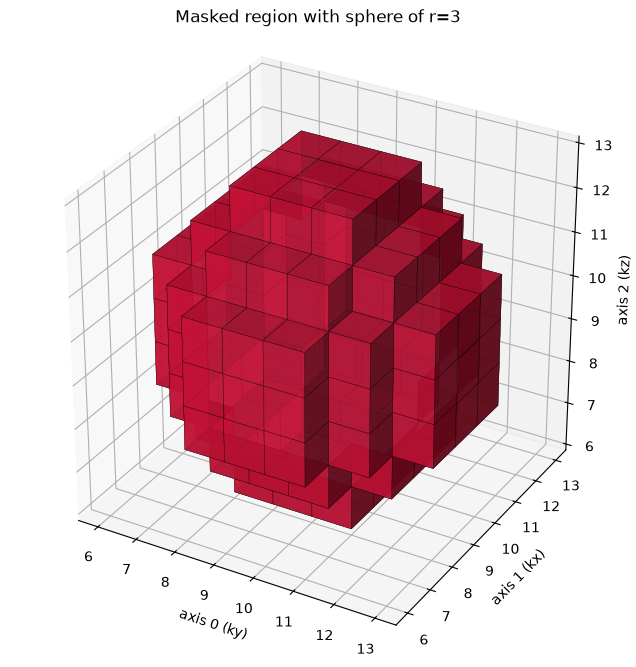

In [11]:
grid_vol_zeropadding = np.abs(enlarged_cartesian[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


cy = cx = cz = inner_wid // 2
r = 3
yy, xx, zz = np.ogrid[:inner_wid, :inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 + (zz - cz)**2 > r**2 + 2




innersidelen=inner_wid
sidelencart = 13
sidelenrad = 7

import matplotlib.pyplot as plt

pad = 3*r
sl = slice(cy - pad, cy + pad)
region = ~mask[sl, sl, sl]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.voxels(region, facecolors='crimson', edgecolor='k', linewidth=0.2, alpha=0.8)
ax.set_xlabel('axis 0 (ky)')
ax.set_ylabel('axis 1 (kx)')
ax.set_zlabel('axis 2 (kz)')
ax.set_title(f'Masked region with sphere of r=3')
ax.set_box_aspect((1, 1, 1))
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


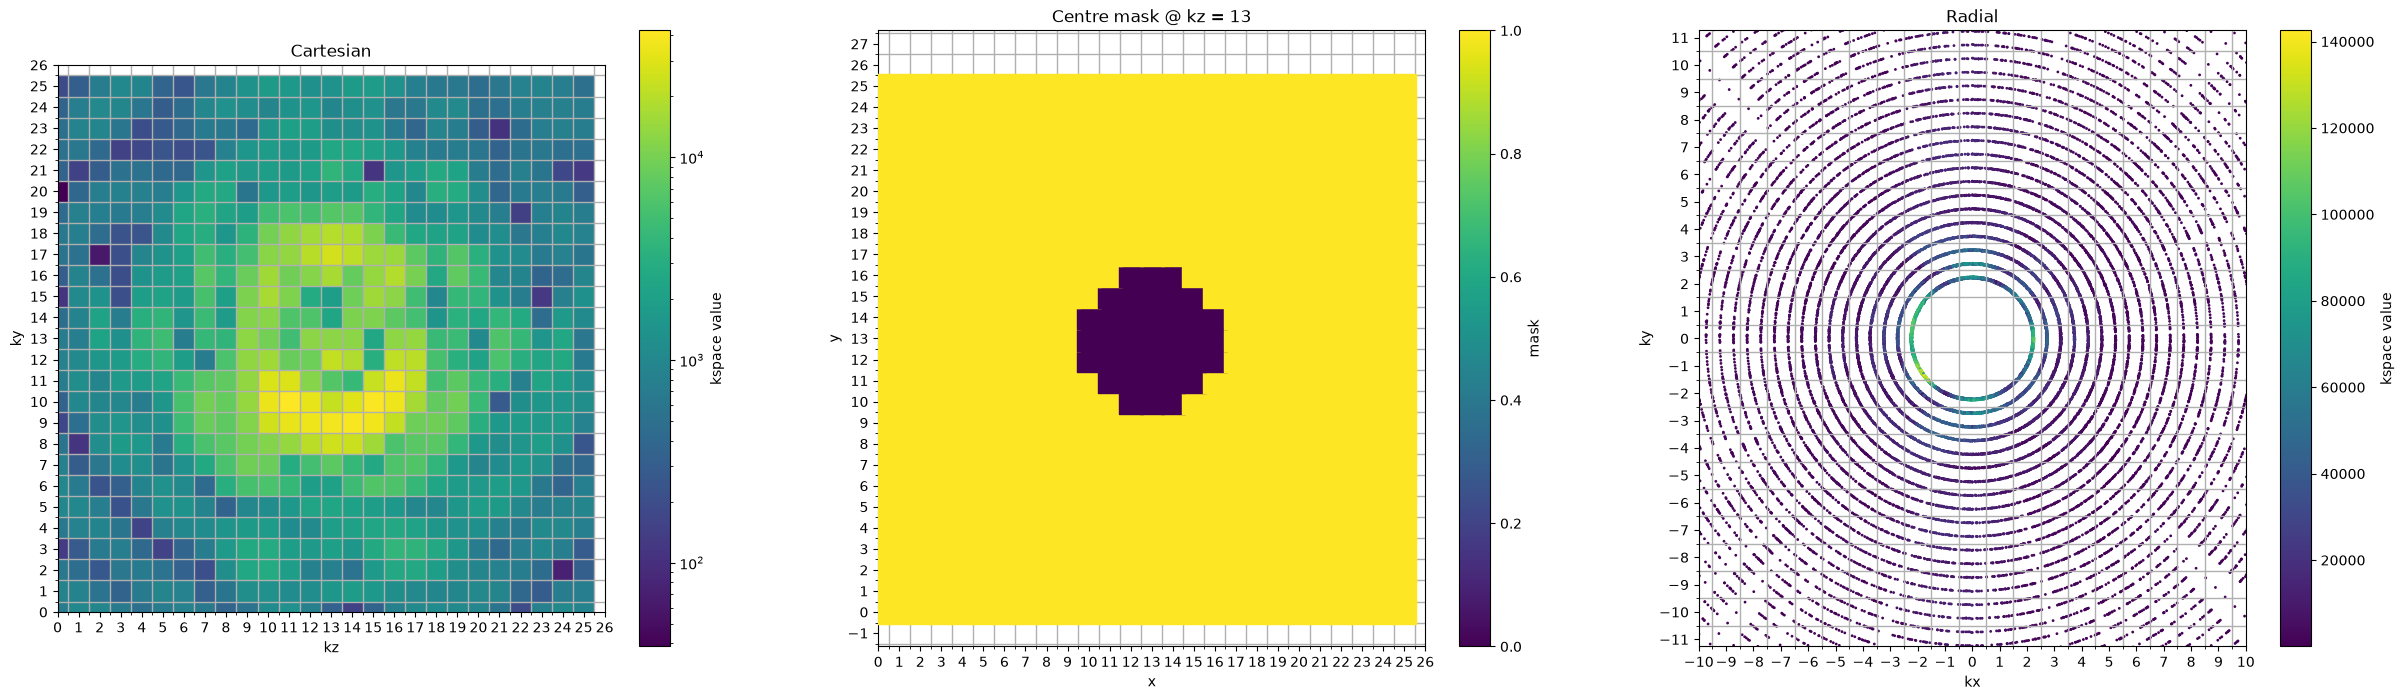

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

grid_vol_zeropadding = np.abs(inner_region[0])
kx_centre_large = grid_vol_zeropadding.shape[0] // 2


im = ax[0].imshow(
    np.abs(grid_vol_zeropadding[kx_centre_large]),
    origin='lower',
    norm=matplotlib.colors.LogNorm(),
)
fig.colorbar(im, ax=ax[0], label='kspace value')
ax[0].set_title('Cartesian')
ax[0].set_xlabel('kz')
ax[0].set_ylabel('ky')
ax[0].set_xlim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].set_ylim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].grid(visible=True, which='minor', linewidth=1)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


mask2d = mask[:, :, cz]

yy, xx = np.mgrid[0:mask2d.shape[0], 0:mask2d.shape[1]]
im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask2d.ravel().astype(int),
                    cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[1], label='mask')
ax[1].set_title(f'Centre mask @ kz = {cz}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].axis('equal')

c = mask2d.shape[0] / 2
ax[1].set_xlim(c - sidelencart, c + sidelencart)
ax[1].set_ylim(c - sidelencart, c + sidelencart)

ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))



tol = 0.5
maskztevis = np.abs(all_ztecoords[:, 0]) < tol

im2 = ax[2].scatter(all_ztecoords[maskztevis, 1], all_ztecoords[maskztevis, 2],c=np.abs(kspacehires[0]).reshape(-1)[maskztevis],s=1)
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(-10,10)
ax[2].set_ylim(-10,10)

plt.show()

In [18]:
print(f"True: {mask.mean():.1%}, False: {(~mask).mean():.1%}, n_true={mask.sum()}")

True: 99.0%, False: 1.0%, n_true=17405


In [13]:
def hankel(kspace, w):
    N_c = kspace.shape[0]
    N_x = kspace.shape[1] - w + 1
    N_y = kspace.shape[2] - w + 1
    N_z = kspace.shape[3] - w + 1
    data_matrix = np.empty((N_c * w*w*w, N_x*N_y*N_z), dtype=np.complex64)
    for c in range(N_c):
        onecoil_matrix = data_matrix[c*w*w*w:(c+1)*w*w*w]
        col_index = 0
        for k in range(N_z):
            for i in range(N_y):
                for j in range(N_x):
                    mat = kspace[c, j:j+w, i:i+w, k:k+w]
                    onecoil_matrix[:, col_index] = mat.reshape(-1, order='F')
                    col_index += 1
    return data_matrix, N_c, N_x, N_y, N_z


def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, Nz, w=3):
    kspace = np.empty((n_coils, Nx, Ny, Nz), dtype=np.complex64)
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    n_win_z = Nz - w + 1

    for c in range(n_coils):
        singlecoil = split_arr[c]
        transposed = singlecoil.T

        recon = np.zeros((Nx, Ny, Nz), dtype=np.complex64)
        counts = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        for index in range(len(transposed)):
            win = transposed[index].reshape((w, w, w), order='F')

            j = index % n_win_x
            i = (index // n_win_x) % n_win_y
            k = index // (n_win_x * n_win_y)

            recon[j:j+w, i:i+w, k:k+w] += win
            counts[j:j+w, i:i+w, k:k+w] += 1

        kspace[c] = recon / counts
    return kspace


def jigsaw3d(output_kspace, isolation_mask, start, end, enlarged_kspace):
    recombined = enlarged_kspace.copy()
    print("copy done")
    recombined[:, start:end, start:end, start:end] = output_kspace
    print("jigsaw doneZ")

    return(recombined)

def rebuild3d(output_kspace, inner_mask, inner_start, inner_end, enlarged_kspace, im_dim):
    recombined = jigsaw3d(output_kspace=output_kspace, isolation_mask = inner_mask, start=inner_start, end=inner_end, enlarged_kspace=enlarged_kspace)
    print("jigsaw3d done")
    filled_ksp = asm.zero_padding3d(recombined, im_dim, im_dim,im_dim)
    return(filled_ksp)

In [ ]:
def softimpute_ALS_time(X_H, M_H, rank, lamda, n_iters, seed):
    I = np.eye(rank)
    m,n = np.shape(X_H)
    rng = np.random.default_rng(seed)
    U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
    V = np.zeros((n, rank),dtype=np.complex64)
    U, _ = np.linalg.qr(U)
    D = I.copy()

    A = np.dot(U, D)
    B = np.dot(V, D)
    iter_count = 0
    ABt = A @ B.conj().T
    iter_times = []
    t_total_start = time.perf_counter()
        
    while iter_count < n_iters:
        t_start = time.perf_counter()
        X_star = np.where(M_H, X_H, ABt)
        B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
        ABt = A @ B.conj().T

        X_star = np.where(M_H, X_H, ABt)
        A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
        ABt = A @ B.conj().T
        iter_count += 1
        t_elapsed = time.perf_counter() - t_start
        iter_times.append(t_elapsed)

    t_total = time.perf_counter() - t_total_start
    t_mean = np.mean(iter_times)

    return (ABt, t_total, t_mean, iter_times)



def softimpute_ALS(X_H, M_H, rank, lamda, n_iters, seed):
        I = np.eye(rank)
        m,n = np.shape(X_H)
        rng = np.random.default_rng(seed)
        U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
        V = rng.standard_normal((n, rank)) + 1j * rng.standard_normal((n, rank))

        D = I.copy()


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T
        norms = {'A': [], 'B': [], 'ABt': [], 'X_star': [], 'rel_change': [], 'residual': []}
        while iter_count < n_iters:
            ABt_prev = ABt
            X_star = np.where(M_H, X_H, ABt)
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
            ABt = A @ B.conj().T
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)

            norms['A'].append(np.linalg.norm(A))
            norms['B'].append(np.linalg.norm(B))
            norms['ABt'].append(np.linalg.norm(ABt))
            norms['X_star'].append(np.linalg.norm(X_star))
            norms['rel_change'].append(np.linalg.norm(ABt - ABt_prev) / np.linalg.norm(ABt))
            norms['residual'].append(np.linalg.norm(ABt - X_star))

            ABt = A @ B.conj().T
            iter_count += 1
        return(ABt, norms)





def LORAKS_imputeals_time(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, enlarged_kspace, inner_mask, inner_start, inner_end, im_dim, seed):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_forhankel = ksp_forhankel * dtg_mask

    hankel_matrix, *_  = hankel(kspace=ksp_forhankel, w=window_size)
    masked_hankel = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = hankel(kspace=masked_hankel, w=window_size)
    masked_hankel = np.real(masked_hankel) > 0.5

    t_als_start = time.perf_counter()
    filled_hankel, norms = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters, seed=seed)
    t_als = time.perf_counter() - t_als_start
    print(f"ALS Done ({t_als:.3f}s)")

    kspace_cart_coils_recon = hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], Nz=ksp_forhankel.shape[3],w=window_size)

    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    filled_ksp = rebuild3d(output_kspace=kspace_cart_coils_recon,inner_mask= inner_mask,inner_start= inner_start,inner_end= inner_end, enlarged_kspace= enlarged_kspace,im_dim=im_dim)

    return (filled_ksp, norms)

In [15]:
import time

timings = {'als': []}
t0 = time.perf_counter()
kspace_cart_coils_recon, norms = LORAKS_imputeals_time(n_iters=50, window_size=10, cartesian_inputkspace=inner_region,dtg_mask=mask, rank= 10, lamda = 5*10**-5, enlarged_kspace = enlarged_cartesian, inner_mask = inner_mask, inner_start = start, inner_end = end, im_dim=126, seed=42)



t1 = time.perf_counter()
timings['als'].append(t1 - t0)

print(f"Als done in {t1-t0}")

ALS Done (159.886s)
copy done
jigsaw doneZ
jigsaw3d done
Als done in 200.09685420799997


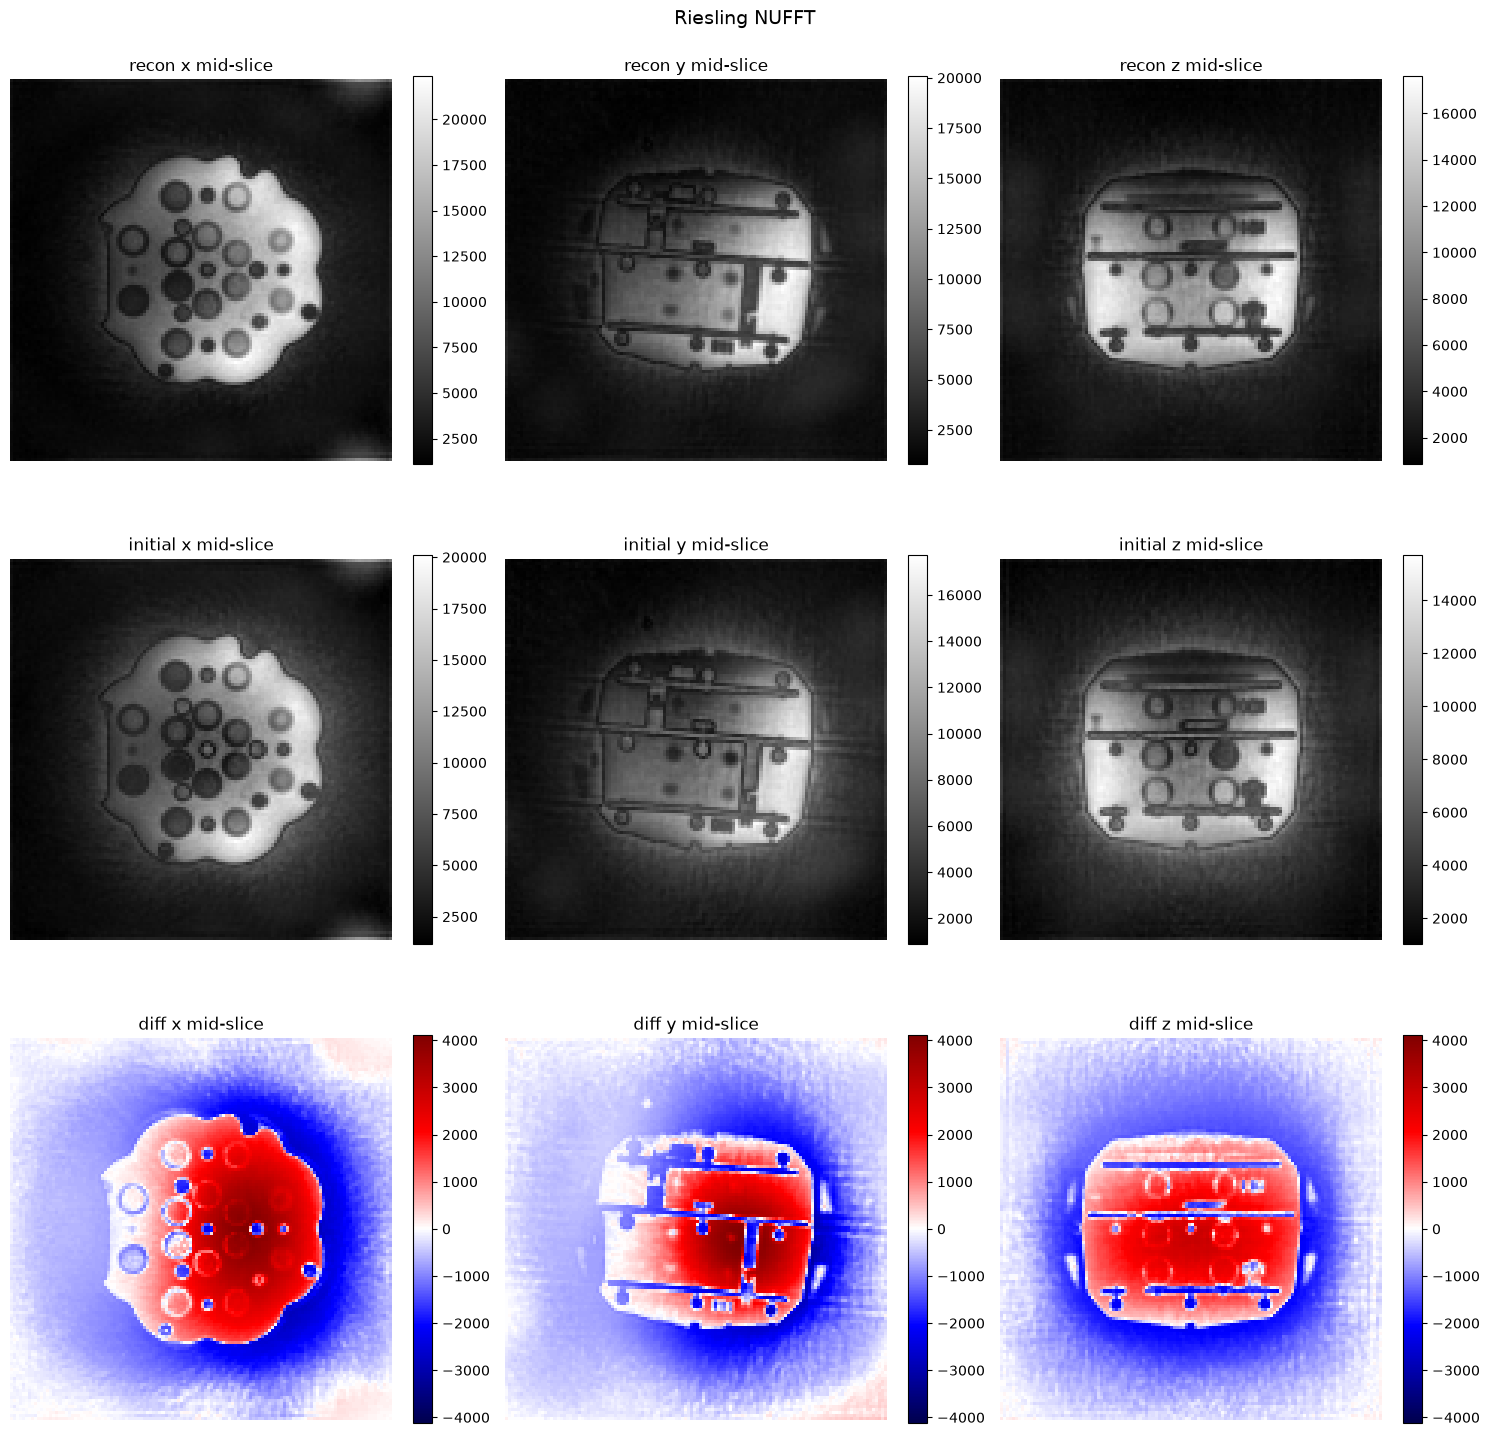

In [16]:
filled_imgrid = sp.ifft(kspace_cart_coils_recon)

riesling_sp_imgrid = np.sum(np.abs(filled_imgrid)**2, axis=0)**0.5

recon_rss = np.sum(np.abs(filled_imgrid)**2, axis=0)**0.5
ref_rss   = np.sum(np.abs(riesling_im)**2, axis=0)**0.5
#ref_rss = ref_rss[::-1, ::-1, ::-1]   # flip all three, adjust as needed
diff_rss = recon_rss - ref_rss

nx, ny, nz = recon_rss.shape
slices = lambda v: [
    (v[nx // 2, :, :], 'x mid-slice'),
    (v[:, ny // 2, :], 'y mid-slice'),
    (v[:, :, nz // 2], 'z mid-slice'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Riesling NUFFT', fontsize=14)
rows = [('recon', recon_rss, 'gray'),
        ('initial',   ref_rss,   'gray'),
        ('diff',  diff_rss,  'seismic')]

for row_axes, (label, vol, cmap) in zip(axes, rows):
    vmax = np.abs(diff_rss).max() if label == 'diff' else None
    for ax, (sl, title) in zip(row_axes, slices(vol)):
        kw = dict(cmap=cmap)
        if label == 'diff':
            kw.update(vmin=-vmax, vmax=vmax)
        im = ax.imshow(sl, **kw) 
        ax.set_title(f'{label} {title}')
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.savefig('riesling_recon.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

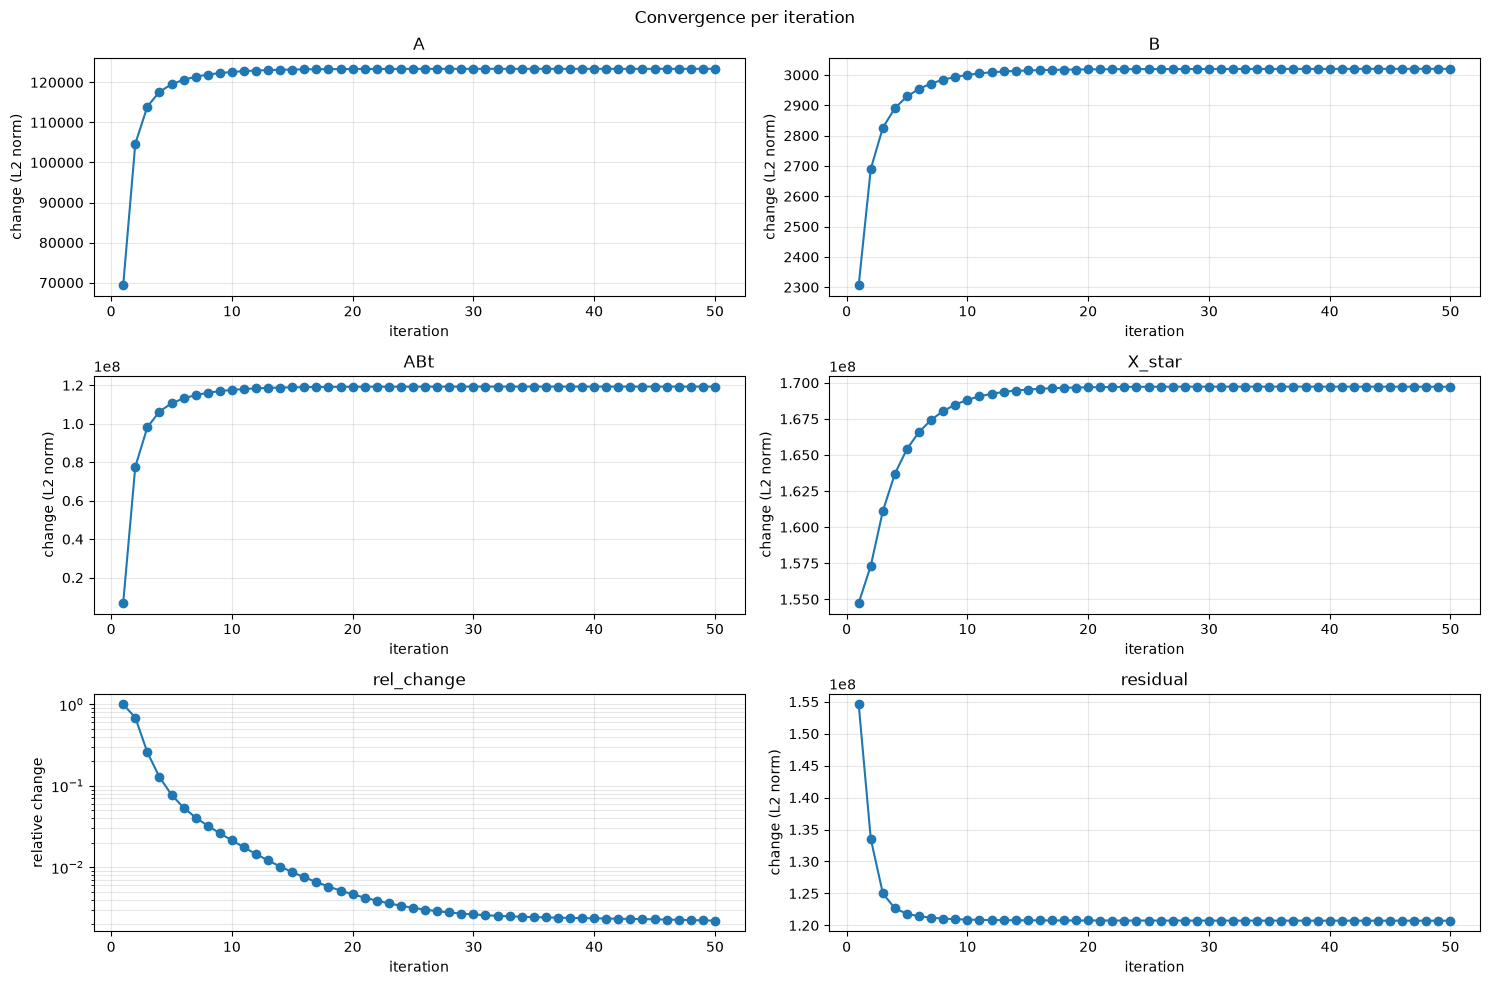

In [24]:
import matplotlib.pyplot as plt

keys = ['A', 'B', 'ABt', 'X_star', 'rel_change', 'residual']

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
for ax, k in zip(axes.flat, keys):
    vals = norms[k]
    iters = range(1, len(vals) + 1)
    ax.plot(iters, vals, marker='o')
    ax.set_title(k)
    ax.set_xlabel('iteration')
    ax.set_ylabel('change (L2 norm)')
    if k == 'rel_change':
        ax.set_yscale('log')
        ax.set_ylabel('relative change')
    ax.grid(True, alpha=0.3, which='both')

fig.suptitle('Convergence per iteration')
fig.tight_layout()
plt.show()